# Importing Libraries

In [1]:
import pandas as pd
import rasterio
import numpy as np
import sys

# Load CSV

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/4_Python_Pipeline/data/ndvi_timeseries.csv")

# Inspect csv file

In [3]:
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.ins_csv import data_overview

data_overview(df)


CSV Inspection

HEAD
                             system:index      NDVI        date  \
0  20240104T044209_20240104T044801_T45RYH  0.431005  2024-01-04   
1  20240129T044031_20240129T044214_T45RYH  0.388728  2024-01-29   

                                     .geo  
0  {"type":"MultiPoint","coordinates":[]}  
1  {"type":"MultiPoint","coordinates":[]}  

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  2 non-null      object 
 1   NDVI          2 non-null      float64
 2   date          2 non-null      object 
 3   .geo          2 non-null      object 
dtypes: float64(1), object(3)
memory usage: 196.0+ bytes

STATS
           NDVI
count  2.000000
mean   0.409867
std    0.029894
min    0.388728
25%    0.399298
50%    0.409867
75%    0.420436
max    0.431005

MISSING VALUES
system:index    0
NDVI            0
date            0
.g

## Parse Date, Sort Chronology and Set Date Index

In [4]:
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Check Temporal Frequency

In [5]:
df.index.to_series().diff()

,date
date,
2024-01-04,NaT
2024-01-29,25 days


In [21]:
df_clean = df.copy()

# remove invalid NDVI range
df_clean = df_clean[
    (df_clean['NDVI'] >= -1) &
    (df_clean['NDVI'] <= 1)
]

# remove missing values
df_clean = df_clean.dropna()

# drop GEE metadata columns (IMPORTANT)
df_clean = df_clean.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
)

# save final dataset
df_clean.to_csv(
    "ndvi_clean.csv",
    index=False
)

#Load Raster

In [6]:
src_red = rasterio.open("/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/4_Python_Pipeline/data/red_band.tif")
src_nir = rasterio.open("/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/4_Python_Pipeline/data/nir_band.tif")

## Inspection

In [7]:
# Inspect Bamd and Shape
print(src_red.read().shape)
print(src_nir.read().shape)


# CHECK CRS
print(src_red.crs)
print(src_nir.crs)

(1, 112, 168)
(1, 112, 168)
EPSG:4326
EPSG:4326


## World Maping

In [8]:
src_red.transform
src_nir.transform

Affine(8.983152841195215e-05, 0.0, 89.21995536652358,
       0.0, -8.983152841195215e-05, 24.840034573416183)

## Read Pixel

In [9]:
red = src_red.read(1)
nir = src_nir.read(1)

# Inspects Values

In [10]:
print(red.min(), red.max())
print(nir.min(), nir.max())

202.5 2499.0
425.0 4998.0


So we need to scale

# Computing NDVI

In [16]:
#checking the nodata
nodata = src_red.nodata

from src.scal_ndvi import ndvi
ndvi_python = ndvi(red, nir, nodata = nodata) #Default Scale = 10000


## LOAD GEE NDVI

In [18]:
gee_src = rasterio.open("/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/4_Python_Pipeline/data/ndvi_gee.tif")

ndvi_gee = gee_src.read(1).astype("float32")

## COMPARE DIFFERENCE

In [19]:
difference = ndvi_python - ndvi_gee
print(np.nanmean(difference))
print(np.nanmax(np.abs(difference)))

-1.3709265771844143e-10
2.9797680878296262e-08


## VISUALIZE HISTOGRAM

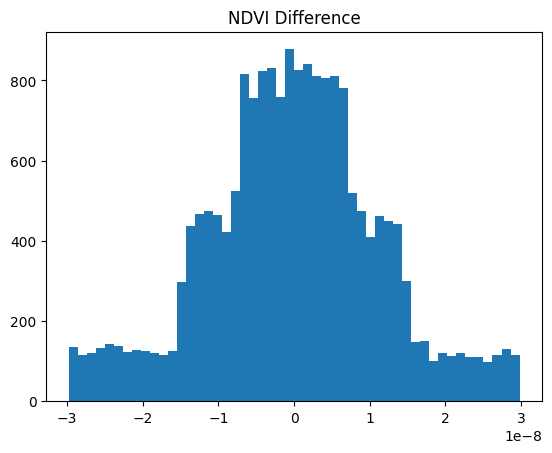

In [20]:
import matplotlib.pyplot as plt

plt.hist(difference.flatten(), bins=50)
plt.title("NDVI Difference")
plt.show()